# Lab 6C: Overfitting and Underfitting in Projectile Motion

**Course:** Machine Learning Lab  
**Topic:** Polynomial regression, underfitting, and overfitting  
**Dataset:** Synthetic projectile motion height-time data

## Lab Objective
The objective of this lab is to compare polynomial models of different degrees and observe how model complexity affects performance. A degree 1 model underfits, a degree 2 model matches the true projectile equation, and a high-degree model can overfit the noisy data.


## 1. Generate Projectile Motion Data
The following code creates height values for a projectile using a quadratic equation. Noise is added to make the data resemble real measurements collected during an experiment.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Data — Projectile Motion ───────────────────────────────────────────────
#
#   A ball is thrown. Height follows:
#   h(t) = -4.9t² + 20t + 2
#
#   True model is degree 2 (a parabola)
#   → degree 1 will GENUINELY underfit
#   → degree 2 is the sweet spot
#   → degree 10 will overfit

np.random.seed(42)

# True parameters
a, b_coef, c = -4.9, 20, 2       # h = at² + bt + c

t = np.linspace(0, 4, 40)        # 0 to 4 seconds, 40 measurements
h_true  = a*t**2 + b_coef*t + c  # true parabola
noise   = np.random.normal(0, 1.5, size=t.shape)  # ±1.5m sensor noise
h_noisy = h_true + noise

# Train / Test split
t_train, h_train = t[:30], h_noisy[:30]   # first 30 = training
t_test,  h_test  = t[30:], h_noisy[30:]   # last  10 = test

## 2. Select Polynomial Models
Three polynomial degrees are selected for comparison. Degree 1 is too simple, degree 2 matches the true projectile motion pattern, and degree 10 is very flexible and may overfit.


In [2]:
# ── 2. Fit Models ─────────────────────────────────────────────────────────────
poly_degrees = [1,      2,           10    ]
colors       = ["blue", "green",     "red" ]
labels       = ["Degree 1 — Underfit  (straight line on a curve)",
                "Degree 2 — Perfect   (matches true physics)",
                "Degree 10 — Overfit  (chasing noise)"]

## 3. Plot and Compare Results
The plot compares the fitted curves with the noisy projectile data. The labels identify which model is underfitting, which is a suitable fit, and which may be overfitting.


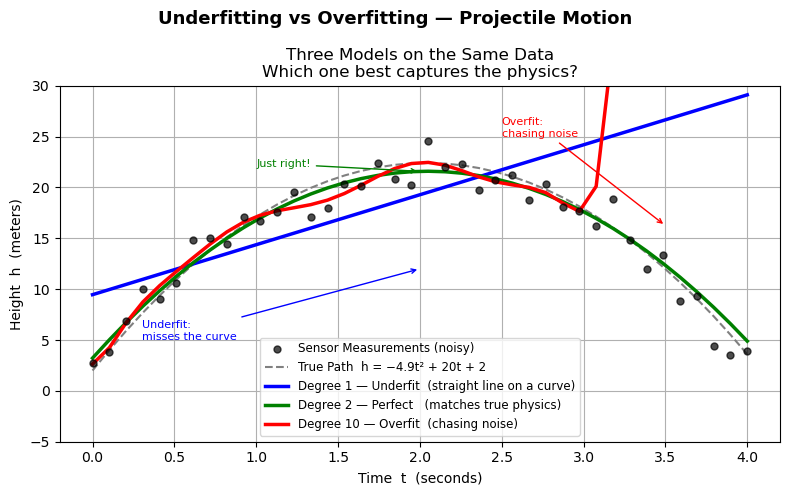


Degree     Train MSE       Test MSE        Verdict
─────────────────────────────────────────────────────────────────
1          10.930          308.927         ❌ Underfit  — straight line misses the parabola
2          1.421           4.331           ✅ Perfect   — matches true physics exactly
10         1.094           14271192.554    ❌ Overfit   — memorized noise, fails on new data

Key Insight:
  Degree 2  → lowest Test MSE  — model learned the physics
  Degree 10 → tiny Train MSE but huge Test MSE — memorized noise


In [3]:
# ── 3. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("Underfitting vs Overfitting — Projectile Motion",
             fontsize=13, fontweight="bold")

ax.scatter(t, h_noisy, color="black", s=25, zorder=5,
           alpha=0.7, label="Sensor Measurements (noisy)")
ax.plot(t, h_true, color="gray", linestyle="--",
        linewidth=1.5, label="True Path  h = −4.9t² + 20t + 2")

for d, color, label in zip(poly_degrees, colors, labels):
    coeffs = np.polyfit(t_train, h_train, d) #train
    h_fit  = np.polyval(coeffs, t) #predict
    ax.plot(t, h_fit, color=color, linewidth=2.5, label=label)

ax.set_xlabel("Time  t  (seconds)")
ax.set_ylabel("Height  h  (meters)")
ax.set_title("Three Models on the Same Data\n"
             "Which one best captures the physics?")
ax.set_ylim(-5, 30)
ax.legend(fontsize=8.5)
ax.grid(True)

ax.annotate("Underfit:\nmisses the curve",
            xy=(2, 12), xytext=(0.3, 5),
            color="blue", fontsize=8,
            arrowprops=dict(arrowstyle="->", color="blue"))
ax.annotate("Overfit:\nchasing noise",
            xy=(3.5, h_noisy[-10]), xytext=(2.5, 25),
            color="red", fontsize=8,
            arrowprops=dict(arrowstyle="->", color="red"))
ax.annotate("Just right!",
            xy=(2, np.polyval(np.polyfit(t_train, h_train, 2), 2)),
            xytext=(1.0, 22),
            color="green", fontsize=8,
            arrowprops=dict(arrowstyle="->", color="green"))

plt.tight_layout()
plt.show()

# ── 4. Summary Table ──────────────────────────────────────────────────────────
print(f"\n{'Degree':<10} {'Train MSE':<15} {'Test MSE':<15} {'Verdict'}")
print("─" * 65)
verdicts = {
    1:  "❌ Underfit  — straight line misses the parabola",
    2:  "✅ Perfect   — matches true physics exactly",
    10: "❌ Overfit   — memorized noise, fails on new data"
}
for d in [1, 2, 10]:
    coeffs    = np.polyfit(t_train, h_train, d)
    train_mse = np.mean((np.polyval(coeffs, t_train) - h_train)**2)
    test_mse  = np.mean((np.polyval(coeffs, t_test)  - h_test) **2)
    print(f"{d:<10} {train_mse:<15.3f} {test_mse:<15.3f} {verdicts[d]}")

print("\nKey Insight:")
print("  Degree 2  → lowest Test MSE  — model learned the physics")
print("  Degree 10 → tiny Train MSE but huge Test MSE — memorized noise")

## Explanation of `np.polyfit`
`np.polyfit` finds the polynomial coefficients that minimize the least-squares error between the fitted curve and the training data. The number of coefficients increases as the polynomial degree increases.


# np.polyfit — Finding the Best Coefficients
This fits a polynomial of degree d to your training data. It finds the coefficients a, b, c... that minimize the least squares error between the polynomial and your data points.

#### degree 1  → [m, c]            2 coefficients
#### degree 2  → [a, b, c]         3 coefficients
#### degree 10 → [a, b, c, d, ...] 11 coefficients

# np.polyval — Using the Coefficients to Predict
This takes the coefficients found above and evaluates the polynomial at every point in t_smooth.

np.polyfit is the teacher — it studies the data and learns the formula.

np.polyval is the student — it uses that formula to answer new questions.

## Clearly Labeled Results
A degree 1 model usually misses the curved motion pattern and underfits. A degree 2 model is suitable because projectile height follows a parabola. A degree 10 model can pass very close to training points but may not generalize well because it follows noise.


## Conclusion
This lab shows the importance of choosing an appropriate model complexity. The best model is not always the most complex model; it is the one that captures the real trend while avoiding unnecessary fitting to noise.
